<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [ ]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,65.248797,0.661965,2.218403,54.801022,2664.833572,161.746908,5.433847,69.615494,0.305584,22.722495,Motor,"Vibration, Wear",Seal
1,85.431935,0.026375,6.777050,54.070419,3694.853834,128.186416,5.903630,62.527246,0.578746,97.826015,Pump,Electrical,Gear
2,95.433968,0.964509,7.945712,76.072659,3104.795356,120.304043,8.227201,80.619240,0.186719,87.673305,Compressor,Overheating,Bearing
3,31.103292,0.951684,6.953793,41.382245,1806.617501,185.538214,7.890565,96.696482,0.692513,98.402500,Pump,Electrical,Bearing
4,44.520999,0.345001,3.790215,38.674800,3087.328620,143.961863,4.966479,83.949109,0.401196,82.876624,Compressor,No Failure,Bearing


In [ ]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,37.225362,0.492608,2.861181,38.506996,2489.174917,158.927674,9.973262,83.669005,0.819720,49.374700,Compressor,"Vibration, Wear",Fan Blade
96,40.995126,0.088197,4.286927,52.740471,4801.481602,234.962678,1.175952,72.780133,0.796022,7.463489,Compressor,Overheating,Seal
97,79.155883,0.154493,8.329400,38.118895,4084.280189,128.121325,9.081727,85.031709,0.467532,8.185258,Compressor,Electrical,Fan Blade
98,75.874211,0.271223,6.778085,42.582804,1742.421188,150.038887,7.247108,98.194427,0.405303,73.870957,Compressor,"Vibration, Wear",Fan Blade
99,36.233113,0.011942,6.715267,61.594629,4551.280308,189.844190,6.263913,98.984374,0.221378,65.159698,Turbine,"Vibration, Wear",Bearing


# **Exploratory Data Analysis**

In [ ]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [ ]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,58.458113,0.494978,5.589233,53.989630,2876.780127,175.669444,5.867364,81.045268,0.445754,48.619977
std,24.512443,0.310896,2.575429,14.370802,1186.816000,40.540709,2.704132,11.484760,0.271897,33.113296
min,20.320393,0.010375,1.042037,30.661656,1009.037570,110.360085,1.017943,60.043961,0.007746,0.145615
25%,35.793026,0.178965,3.421494,41.693330,1888.698790,137.034418,3.645887,72.166132,0.223858,18.394565
50%,56.390459,0.495228,5.764696,54.979951,2939.775194,173.492905,5.886022,81.426846,0.393698,45.954248
75%,79.420284,0.720275,7.754035,65.997571,3847.647639,214.301763,8.076702,90.020137,0.667306,80.992450
max,99.334626,0.998470,9.896378,79.740448,4883.011526,239.978718,9.997877,99.688263,0.986856,99.016701


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000  -0.098559  0.026562  0.033371  0.123672  0.067365   
Vibration      -0.098559   1.000000  0.079580 -0.047082 -0.127621 -0.029628   
Pressure        0.026562   0.079580  1.000000  0.051368  0.106741  0.016445   
Humidity        0.033371  -0.047082  0.051368  1.000000  0.176023  0.233249   
RPM             0.123672  -0.127621  0.106741  0.176023  1.000000 -0.029281   
Voltage         0.067365  -0.029628  0.016445  0.233249 -0.029281  1.000000   
Current         0.003352   0.159355  0.071099 -0.163830 -0.062995  0.028750   
Sound_Level    -0.122150  -0.029496  0.059524  0.209411 -0.138311  0.099920   
Oil_Quality     0.023152  -0.084275  0.031498  0.057856  0.008213  0.095310   
Load            0.014489   0.125673  0.291596  0.141592  0.216763  0.024596   

              Current  Sound_Level  Oil_Quality      Load  
Temperature  0.003352    -0.122150     0.023152  0.014489  
Vibration 

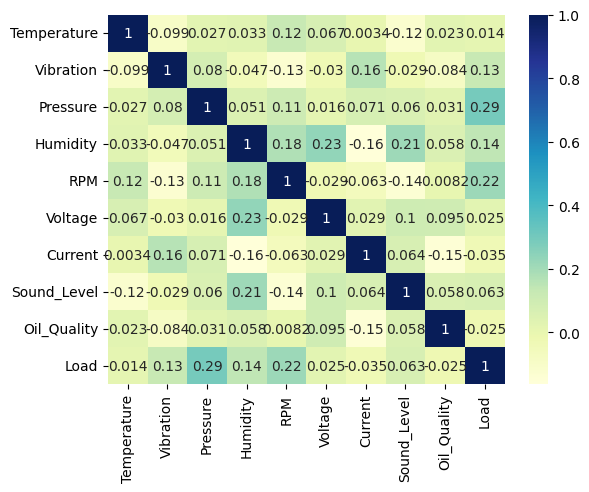

In [ ]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [ ]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [ ]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.95
Recall: 0.95
Precision: 0.9583333333333334
F1 Score: 0.9472727272727273
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7
           2       0.83      1.00      0.91         5
           3       1.00      0.67      0.80         3

    accuracy                           0.95        20
   macro avg       0.96      0.92      0.93        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Absolute Error:', np.mean(np.abs(y_test - y_pred)))

Mean Absolute Error: 0.0


# **Bagging**

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.95
Recall: 0.95
Precision: 0.9583333333333334
F1 Score: 0.9472727272727273
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7
           2       0.83      1.00      0.91         5
           3       1.00      0.67      0.80         3

    accuracy                           0.95        20
   macro avg       0.96      0.92      0.93        20
weighted avg       0.96      0.95      0.95        20



In [ ]:
cv = cross_val_score(pipeline, X, y, cv=10)

print(f"Cross-validation scores: {cv}")
print(f"Mean CV accuracy: {np.mean(cv):.2f}")

Cross-validation scores: [1.  1.  0.9 1.  1.  1.  1.  1.  0.9 1. ]
Mean CV accuracy: 0.98


In [ ]:
bagging_classifier = BaggingClassifier(estimator=pipeline, n_estimators=150, random_state=42)

bagging_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                            ('classifier',
                                             RandomForestClassifier(random_state=42))]),
                  n_estimators=150, random_state=42)

In [ ]:
y_pred = bagging_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_pred, y_test))

Accuracy: 1.0
Recall: 1.0
Precision: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         3

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
cv = cross_val_score(bagging_classifier, X, y, cv=10)

print(f"Cross-validation scores: {cv}")
print(f"Mean CV accuracy: {np.mean(cv):.2f}")